Шаг 1: Файл data.csv загружен успешно.
        Дата  Склад Контрагент Номенклатура  Количество
0 2018-01-04      1  address_0    product_0           4
1 2018-01-04      1  address_0    product_1           4
2 2018-01-04      1  address_0    product_2           5
3 2018-01-04      1  address_0    product_3          10
4 2018-01-04      1  address_0    product_4           2
Шаг 2: Очистка завершена. Удалено 3 дней-выбросов.
Шаг 3: Топовый товар (Склад 3, среды, лето): product_1
Шаг 4-5: Данные объединены. Итого строк для графика: 0


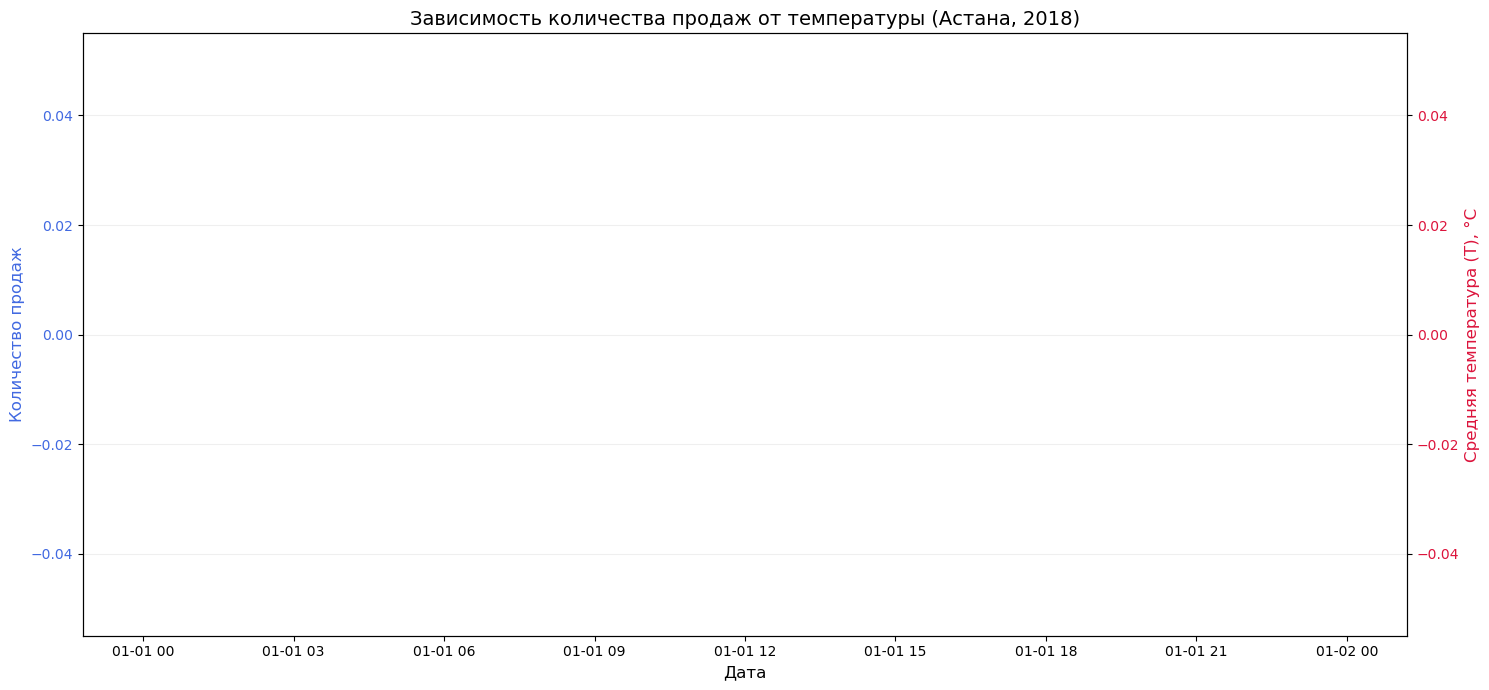

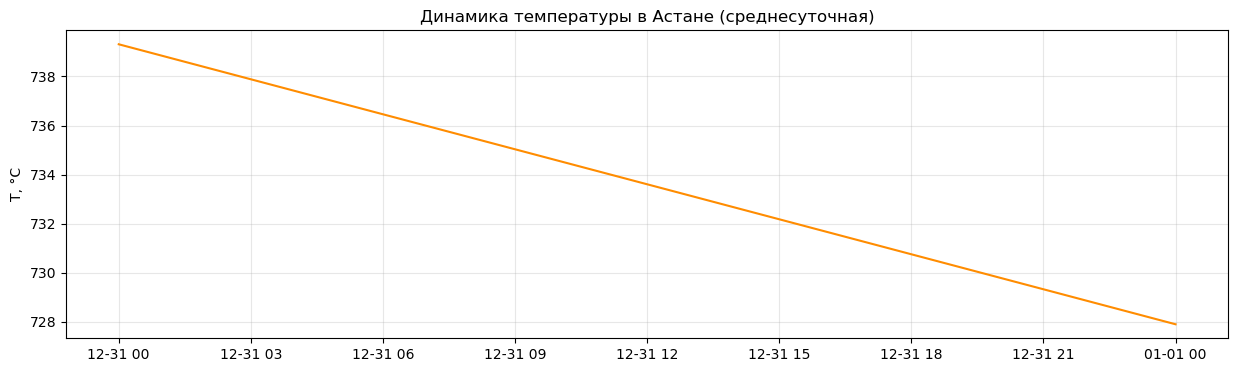

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. ЧТЕНИЕ ДАННЫХ И ПРОВЕРКА ФОРМАТОВ ---
df = pd.read_csv('data.csv')
df['Дата'] = pd.to_datetime(df['Дата'])
print("Шаг 1: Файл data.csv загружен успешно.")
print(df.head())

# --- 2. ОЧИСТКА ОТ ВЫБРОСОВ (IQR) ---
# Считаем сумму продаж по дням для корректного поиска аномалий
daily_sales = df.groupby('Дата')['Количество'].sum().reset_index()
Q1 = daily_sales['Количество'].quantile(0.25)
Q3 = daily_sales['Количество'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Фильтруем даты, не являющиеся выбросами
valid_dates = daily_sales[(daily_sales['Количество'] >= lower_bound) & 
                          (daily_sales['Количество'] <= upper_bound)]['Дата']
df_cleaned = df[df['Дата'].isin(valid_dates)].copy()

# Формируем grouped_df (необходим для объединения с погодой)
grouped_df = df_cleaned.groupby('Дата')['Количество'].sum().reset_index()
grouped_df.columns = ['Дата', 'Количество продаж']
print(f"Шаг 2: Очистка завершена. Удалено {len(daily_sales) - len(valid_dates)} дней-выбросов.")

# --- 3. ТОПОВЫЙ ТОВАР (Склад 3, Среды, Июнь-Август) ---
df_cleaned['Month'] = df_cleaned['Дата'].dt.month
df_cleaned['DayOfWeek'] = df_cleaned['Дата'].dt.dayofweek # 2 - Среда

target_filter = (df_cleaned['Склад'] == 3) & \
                (df_cleaned['Month'].isin([6, 7, 8])) & \
                (df_cleaned['DayOfWeek'] == 2)

top_product = df_cleaned[target_filter].groupby('Номенклатура')['Количество'].sum().idxmax()
print(f"Шаг 3: Топовый товар (Склад 3, среды, лето): {top_product}")

# --- 4. РАБОТА С ПОГОДОЙ (rp5.ru) ---
# Читаем архив (кодировка cp1251, разделитель ';', пропускаем 6 строк заголовка)
weather = pd.read_csv('astana_weather.csv', sep=';', skiprows=6, encoding='cp1251')

# Очищаем названия колонок от лишних кавычек
weather.columns = [c.replace('"', '').strip() for c in weather.columns]

# ПРЕОБРАЗОВАНИЕ: убираем время (03:00, 06:00 и т.д.), оставляя только Дату
weather['Дата'] = pd.to_datetime(weather['Местное время в Астане'], dayfirst=True).dt.normalize()

# Считаем среднюю температуру T за каждые сутки
weather_daily = weather.groupby('Дата')['T'].mean().reset_index()

# --- 5. ОБЪЕДИНЕНИЕ ТАБЛИЦ ---
final_df = pd.merge(grouped_df, weather_daily, on='Дата', how='inner')
print(f"Шаг 4-5: Данные объединены. Итого строк для графика: {len(final_df)}")

# --- 6. ВИЗУАЛИЗАЦИЯ ---
# Создаем график с двойной осью Y (одна для продаж, другая для температуры)

fig, ax1 = plt.subplots(figsize=(15, 7))

# Рисуем количество продаж
ax1.set_xlabel('Дата', fontsize=12)
ax1.set_ylabel('Количество продаж', color='royalblue', fontsize=12)
ax1.plot(final_df['Дата'], final_df['Количество продаж'], color='royalblue', lw=2, label='Продажи')
ax1.tick_params(axis='y', labelcolor='royalblue')

# Создаем вторую ось для температуры
ax2 = ax1.twinx()
ax2.set_ylabel('Средняя температура (T), °C', color='crimson', fontsize=12)
ax2.plot(final_df['Дата'], final_df['T'], color='crimson', ls='--', alpha=0.7, label='Температура')
ax2.tick_params(axis='y', labelcolor='crimson')

plt.title('Зависимость количества продаж от температуры (Астана, 2018)', fontsize=14)
plt.grid(True, alpha=0.2)
fig.tight_layout()
plt.show()

# Отдельный график только температуры
plt.figure(figsize=(15, 4))
plt.plot(weather_daily['Дата'], weather_daily['T'], color='darkorange', lw=1.5)
plt.title('Динамика температуры в Астане (среднесуточная)')
plt.ylabel('T, °C')
plt.grid(True, alpha=0.3)
plt.show()